# Stock Price Prediction with a Transformer: Moroccan Market

Trains a Transformer model (PyTorch) to predict the daily **closing price** of 10 companies listed on the Casablanca Stock Exchange, using that day's **Open, High and Low** prices as input.

For each company the notebook:
1. loads the price history from `data/` (Jan 2018 to Dec 2023),
2. z-score normalizes the prices,
3. splits the rows 70 / 15 / 15 into train / validation / test,
4. trains the model for 100 epochs and reports MAE, MSE, RMSE, MAPE, R² and correlation,
5. plots the price history, the loss curves and predicted vs. true values.

A summary table across all companies is printed at the end and saved to `results/summary_metrics.csv`.

This notebook accompanies the paper *Optimizing Investment Portfolios Using Machine Learning: A Case Study on the Moroccan Market* (see `paper/`).

## Setup

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fixing the random seeds so results are reproducible between runs
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Finding the data folder whether the notebook is run from the repo root or from notebooks/
DATA_DIR = next(p for p in [Path("data"), Path("../data")] if p.exists())
RESULTS_DIR = DATA_DIR.parent / "results"

In [2]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def calculate_mape(y_true, y_pred):
    # Filter out zeros to avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [3]:
# Moroccan companies and their CSV files in data/
companies = {
    'Attijariwafa Bank': 'attijariwafa_bank.csv',
    'BCP': 'bcp.csv',
    'Bmce Bank': 'bmce_bank.csv',
    'Ciments Du Maroc': 'ciments_du_maroc.csv',
    'Itissalat Al-Maghrib': 'itissalat_al_maghrib.csv',
    'LafargeHolcim Maroc': 'lafargeholcim_maroc.csv',
    'Managem': 'managem.csv',
    "Societe d'Exploitation des Ports": 'societe_exploitation_des_ports.csv',
    'Taqa Morocco SA': 'taqa_morocco.csv',
    'Travaux Generaux De Construction': 'travaux_generaux_de_construction.csv',
}

## Model, training and evaluation for one company

In [4]:
# function to process and predict stock data
def process_and_predict_stock(file_path, company_name):
    print(f"\n{'='*80}")
    print(f"Processing {company_name}")
    print(f"{'='*80}")

    try:
        # Loading stock data from CSV
        stock_data = pd.read_csv(file_path)
        print(f"Loaded {len(stock_data)} records")

        # Checking the columns in the data
        print("Columns in the loaded data:", stock_data.columns.tolist())

        # Converting 'Date' to datetime and set as index
        stock_data['Date'] = pd.to_datetime(stock_data['Date'])
        stock_data.set_index('Date', inplace=True)

        # Converting string columns to float if needed
        numeric_columns = ['Open', 'High', 'Low', 'Close']
        for col in numeric_columns:
            if not pd.api.types.is_numeric_dtype(stock_data[col]):
                # Replacing any non-numeric characters and converting to float
                stock_data[col] = stock_data[col].str.replace(r'[^\d.]', '', regex=True).astype(float)

        # Plotting the historical stock data
        plt.figure(figsize=(12, 6))
        plt.plot(stock_data.index, stock_data['Close'])
        plt.title(f"{company_name} - Historical Stock Prices")
        plt.xlabel('Date')
        plt.ylabel('Close Price')
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Normalizing data
        required_columns = ['Low', 'Open', 'High', 'Close']

        # Checking if all required columns exist
        for col in required_columns:
            if col not in stock_data.columns:
                raise ValueError(f"Required column {col} not found in the data")

        # Using only the required columns
        data_to_normalize = stock_data[required_columns].values

        # Converting the data to PyTorch tensor
        tensor_data = torch.tensor(data_to_normalize, dtype=torch.float32)

        # Calculating mean and standard deviation for each column
        mean = tensor_data.mean(dim=0)
        std = tensor_data.std(dim=0)

        # Normalizing the data
        normalized_data = (tensor_data - mean) / std

        # Converting the normalized data back to a DataFrame
        df_normalized = pd.DataFrame(normalized_data.numpy(), columns=required_columns)

        # Adding 'Date' column back to the DataFrame
        df_normalized['Date'] = stock_data.index
        data = df_normalized

        # Defining the percentage of data for training, validation, and testing
        train_percent = 0.7
        val_percent = 0.15
        test_percent = 0.15

        # Calculating the sizes of the train, validation, and test sets
        train_size = int(train_percent * len(data))
        val_size = int(val_percent * len(data))
        test_size = len(data) - train_size - val_size

        print(f"Training data: {train_size} records")
        print(f"Validation data: {val_size} records")
        print(f"Test data: {test_size} records")

        # Splitting the data into train, validation, and test sets
        train_data = data.iloc[:train_size]
        val_data = data.iloc[train_size:train_size + val_size]
        test_data = data.iloc[train_size + val_size:]

        # Defining the features and target columns
        feature_columns = ['Low', 'Open', 'High']
        target_column = 'Close'

        # Extracting features and target for each dataset
        train_features = train_data[feature_columns].values
        train_target = train_data[target_column].values

        val_features = val_data[feature_columns].values
        val_target = val_data[target_column].values

        test_features = test_data[feature_columns].values
        test_target = test_data[target_column].values

        # Converting data to PyTorch tensors
        train_features = torch.tensor(train_features, dtype=torch.float32)
        train_target = torch.tensor(train_target, dtype=torch.float32)
        val_features = torch.tensor(val_features, dtype=torch.float32)
        val_target = torch.tensor(val_target, dtype=torch.float32)
        test_features = torch.tensor(test_features, dtype=torch.float32)
        test_target = torch.tensor(test_target, dtype=torch.float32)

        # Defining the Transformer model
        class TransformerModel(nn.Module):
            def __init__(self, input_size, hidden_size, output_size, num_layers, num_attention_heads):
                super(TransformerModel, self).__init__()
                self.embedding = nn.Linear(input_size, hidden_size)
                self.transformer = nn.Transformer(
                    d_model=hidden_size,
                    nhead=num_attention_heads,
                    num_encoder_layers=num_layers,
                    num_decoder_layers=num_layers
                )
                self.fc_output = nn.Linear(hidden_size, output_size)

            def forward(self, x):
                x = self.embedding(x)
                x = x.permute(1, 0, 2)  # Adjusting input shape for the transformer
                x = self.transformer(x, x)  # Setting source and target as the same data
                x = x.permute(1, 0, 2)  # Restoring the original shape
                x = self.fc_output(x[:, -1, :])  # Using the last layer's output for prediction
                return x

        # Defining hyperparameters
        input_size = len(feature_columns)
        hidden_size = 64
        output_size = 1
        num_layers = 2
        num_attention_heads = 4
        learning_rate = 0.001
        num_epochs = 100

        # Creating the model instance
        model = TransformerModel(input_size, hidden_size, output_size, num_layers, num_attention_heads)

        # Defining the loss function and optimizer
        criterion = nn.MSELoss()  # Mean Squared Error loss
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        # Lists to store training, validation, and test losses
        train_losses = []
        val_losses = []
        test_losses = []

        # Training loop
        print("Starting training...")
        start_time = time.time()

        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()

            # Forward pass
            outputs = model(train_features.unsqueeze(1))

            # Calculate the loss
            loss = criterion(outputs, train_target.unsqueeze(1))

            # Backpropagation and optimization
            loss.backward()
            optimizer.step()

            # Store the training loss
            train_losses.append(loss.item())

            # Validation loss
            model.eval()
            with torch.no_grad():
                val_outputs = model(val_features.unsqueeze(1))
                val_loss = criterion(val_outputs, val_target.unsqueeze(1))

            # Store the validation loss
            val_losses.append(val_loss.item())

            # Test loss
            with torch.no_grad():
                test_outputs = model(test_features.unsqueeze(1))
                test_loss = criterion(test_outputs, test_target.unsqueeze(1))

            # Store the test loss for each epoch
            test_losses.append(test_loss.item())

            # Print progress every 10 epochs
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f} seconds")

        # Plotting the training and validation losses
        plt.figure(figsize=(12, 6))
        plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
        plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
        plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'{company_name} - Training and Validation Losses Over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Switching the model to evaluation mode
        model.eval()

        # Making predictions on the validation set
        with torch.no_grad():
            val_predictions = model(val_features.unsqueeze(1))

        # Converting predictions and targets back to numpy arrays
        val_predictions = val_predictions.squeeze(1).numpy()
        val_target_numpy = val_target.numpy()

        # Calculating evaluation metrics for validation set
        mae_val = mean_absolute_error(val_target_numpy, val_predictions)
        mse_val = mean_squared_error(val_target_numpy, val_predictions)
        rmse_val = np.sqrt(mse_val)
        mape_val = calculate_mape(val_target_numpy, val_predictions)
        r2_val = r2_score(val_target_numpy, val_predictions)

        # Evaluation metrics for validation set
        print('\nValidation Set Metrics:')
        print(f'Mean Absolute Error (MAE): {mae_val:.4f}')
        print(f'Mean Squared Error (MSE): {mse_val:.4f}')
        print(f'Root Mean Squared Error (RMSE): {rmse_val:.4f}')
        print(f'Mean Absolute Percentage Error (MAPE): {mape_val:.4f}')
        print(f'R² Score: {r2_val:.4f}')

        # Making predictions on the test set
        with torch.no_grad():
            test_predictions = model(test_features.unsqueeze(1))

        # Converting predictions and targets back to numpy arrays
        test_predictions = test_predictions.squeeze(1).numpy()
        test_target_numpy = test_target.numpy()

        # Calculating evaluation metrics for test set
        mae_test = mean_absolute_error(test_target_numpy, test_predictions)
        mse_test = mean_squared_error(test_target_numpy, test_predictions)
        rmse_test = np.sqrt(mse_test)
        mape_test = calculate_mape(test_target_numpy, test_predictions)
        r2_test = r2_score(test_target_numpy, test_predictions)

        # Printing the evaluation metrics for test set
        print('\nTest Set Metrics:')
        print(f'Mean Absolute Error (MAE): {mae_test:.4f}')
        print(f'Mean Squared Error (MSE): {mse_test:.4f}')
        print(f'Root Mean Squared Error (RMSE): {rmse_test:.4f}')
        print(f'Mean Absolute Percentage Error (MAPE): {mape_test:.4f}')
        print(f'R² Score: {r2_test:.4f}')

        # Plotting the predicted values against true values for the test set
        plt.figure(figsize=(12, 6))
        plt.plot(test_target_numpy, label='True Values')
        plt.plot(test_predictions, label='Predicted Values', linestyle='dashed')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Close Price')
        plt.title(f'{company_name} - True vs Predicted Values for Test Set')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calculating correlations between true and predicted values
        correlation = np.corrcoef(test_target_numpy, test_predictions)[0, 1]
        print(f'\nCorrelation between true and predicted values: {correlation:.4f}')

        # Return results for comparison
        return {
            'company': company_name,
            'train_size': train_size,
            'val_size': val_size,
            'test_size': test_size,
            'metrics': {
                'mae': mae_test,
                'mse': mse_test,
                'rmse': rmse_test,
                'mape': mape_test,
                'r2': r2_test,
                'correlation': correlation
            },
            'training_time': training_time
        }

    except Exception as e:
        print(f"Error processing {company_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

## Run for all companies


Processing Attijariwafa Bank
Loaded 1494 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


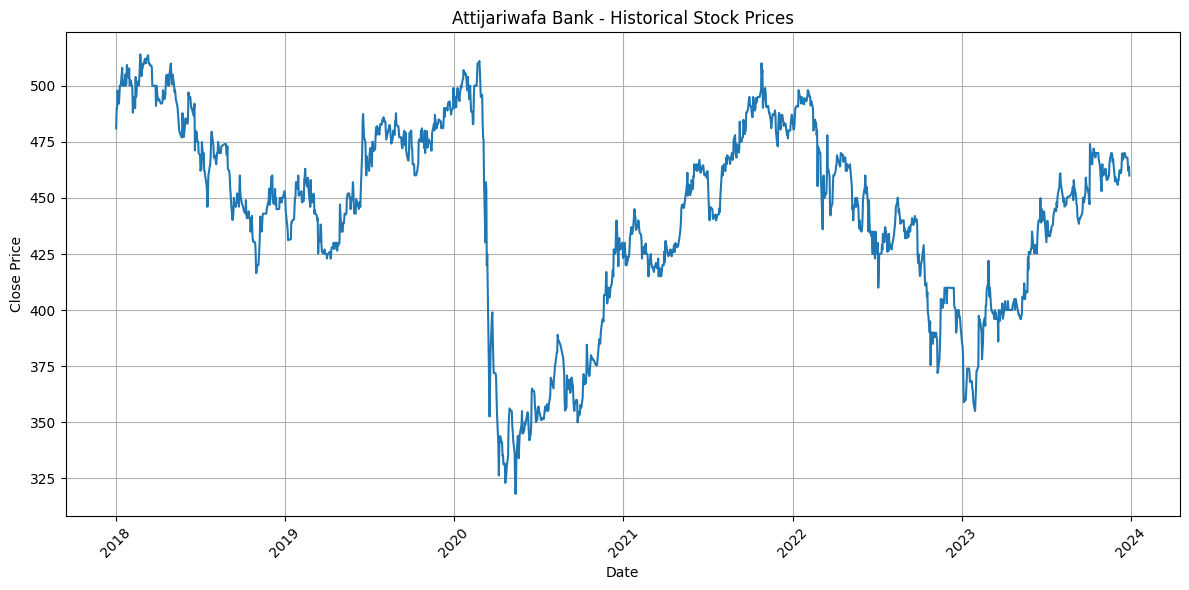

Training data: 1045 records
Validation data: 224 records
Test data: 225 records


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Starting training...


Epoch [10/100], Train Loss: 0.1417, Val Loss: 0.1298, Test Loss: 0.0856


Epoch [20/100], Train Loss: 0.1094, Val Loss: 0.0560, Test Loss: 0.1128


...

Epoch [60/100], Train Loss: 0.0264, Val Loss: 0.0148, Test Loss: 0.0178


Epoch [70/100], Train Loss: 0.0234, Val Loss: 0.0099, Test Loss: 0.0117


Epoch [80/100], Train Loss: 0.0217, Val Loss: 0.0090, Test Loss: 0.0108


Epoch [90/100], Train Loss: 0.0203, Val Loss: 0.0090, Test Loss: 0.0111


Epoch [100/100], Train Loss: 0.0186, Val Loss: 0.0089, Test Loss: 0.0113
Training completed in 21.70 seconds


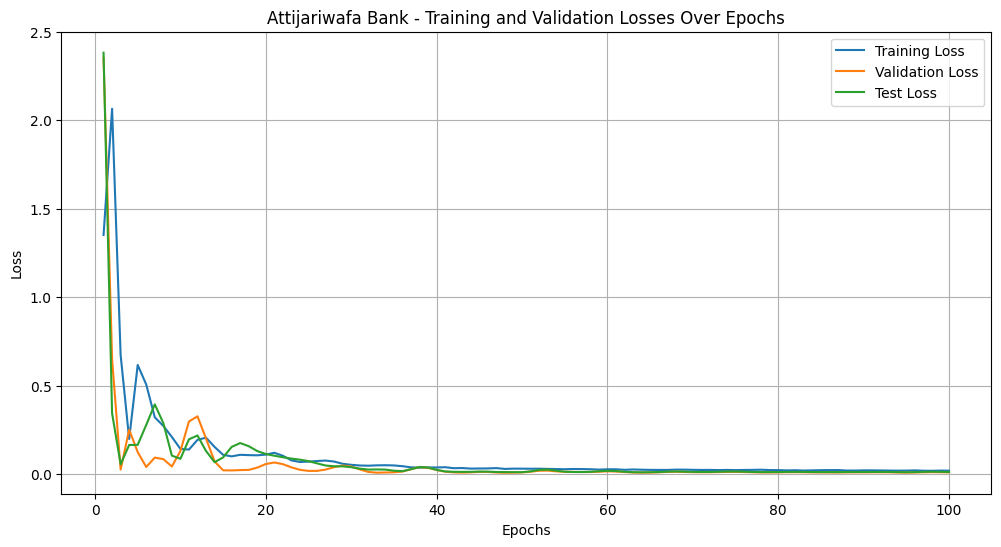


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0764
Mean Squared Error (MSE): 0.0089
Root Mean Squared Error (RMSE): 0.0945
Mean Absolute Percentage Error (MAPE): 55.3726
R² Score: 0.9516

Test Set Metrics:
Mean Absolute Error (MAE): 0.0878
Mean Squared Error (MSE): 0.0113
Root Mean Squared Error (RMSE): 0.1062
Mean Absolute Percentage Error (MAPE): 35.1283
R² Score: 0.9678


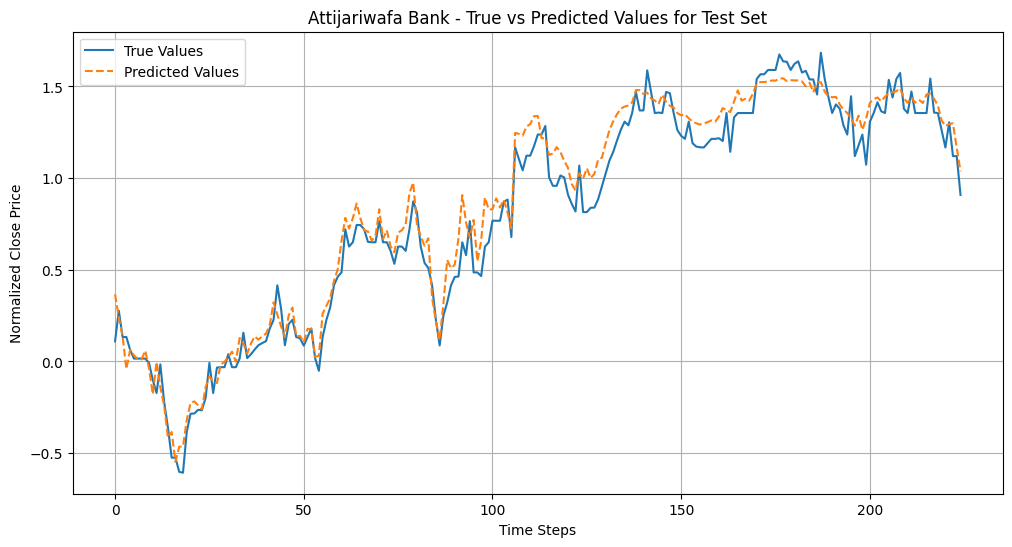


Correlation between true and predicted values: 0.9884

Processing BCP
Loaded 1482 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


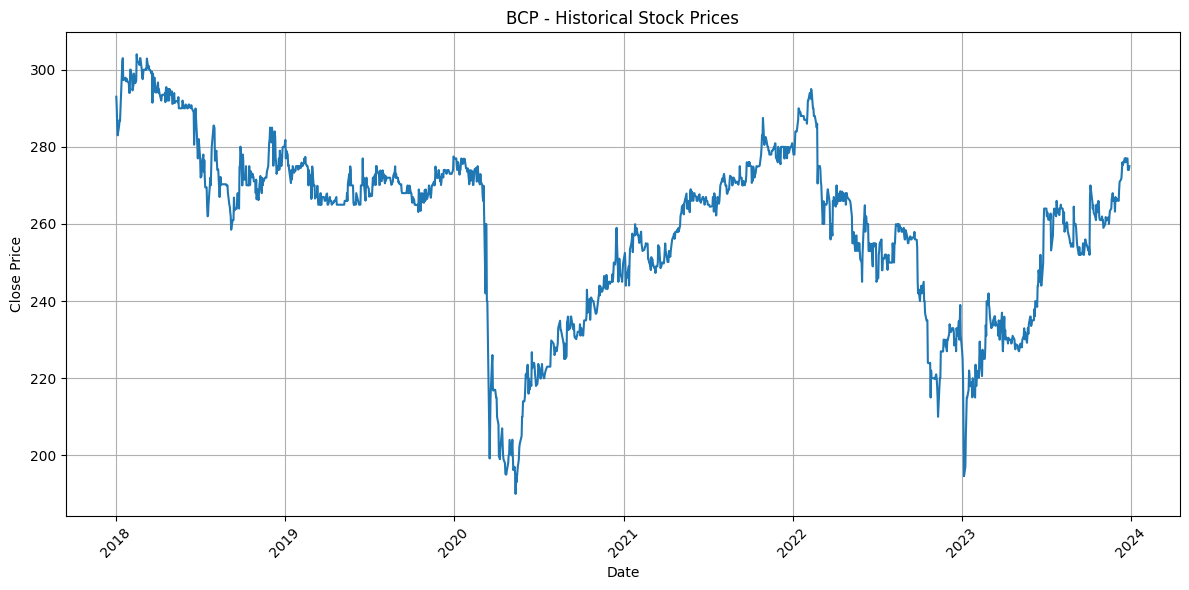

Training data: 1037 records
Validation data: 222 records
Test data: 223 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1916, Val Loss: 0.0308, Test Loss: 0.5487


Epoch [20/100], Train Loss: 0.1111, Val Loss: 0.0206, Test Loss: 0.4322


Epoch [30/100], Train Loss: 0.0779, Val Loss: 0.0245, Test Loss: 0.1606


...

Epoch [60/100], Train Loss: 0.0280, Val Loss: 0.0057, Test Loss: 0.0489


Epoch [70/100], Train Loss: 0.0258, Val Loss: 0.0078, Test Loss: 0.0319


Epoch [80/100], Train Loss: 0.0237, Val Loss: 0.0061, Test Loss: 0.0252


Epoch [90/100], Train Loss: 0.0222, Val Loss: 0.0067, Test Loss: 0.0237


Epoch [100/100], Train Loss: 0.0208, Val Loss: 0.0063, Test Loss: 0.0216
Training completed in 21.31 seconds


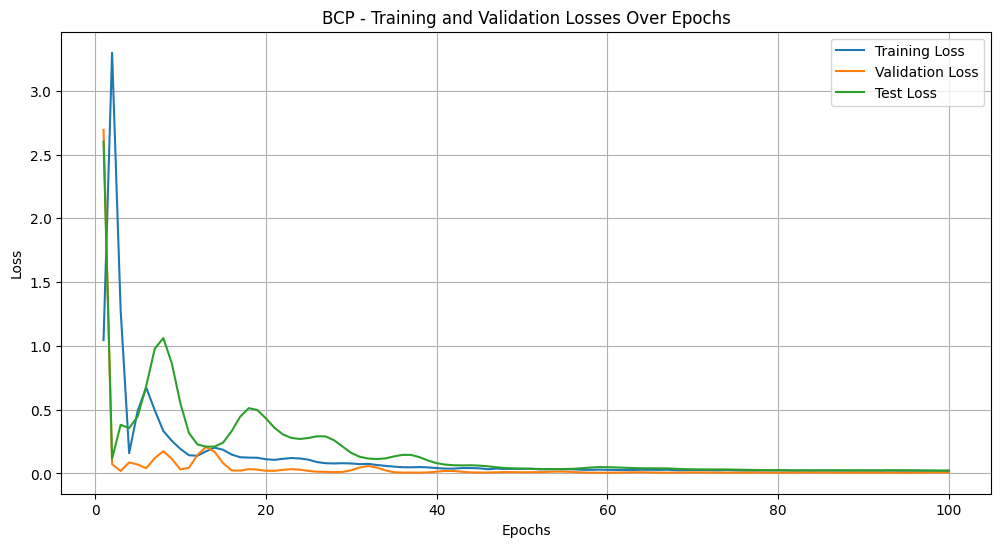


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0611
Mean Squared Error (MSE): 0.0063
Root Mean Squared Error (RMSE): 0.0792
Mean Absolute Percentage Error (MAPE): 13.4534
R² Score: 0.8551

Test Set Metrics:
Mean Absolute Error (MAE): 0.1141
Mean Squared Error (MSE): 0.0216
Root Mean Squared Error (RMSE): 0.1471
Mean Absolute Percentage Error (MAPE): 18.0600
R² Score: 0.9289


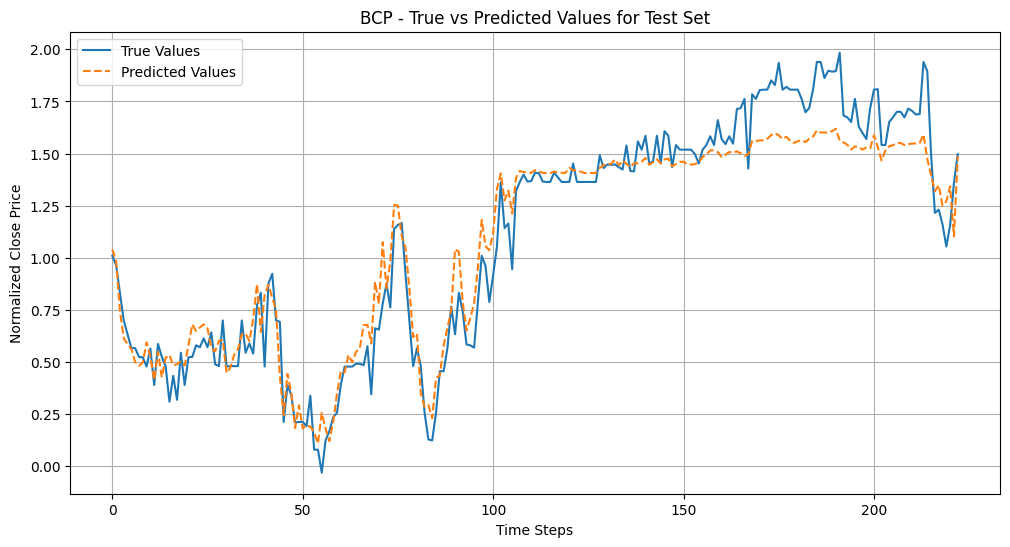


Correlation between true and predicted values: 0.9715

Processing Bmce Bank
Loaded 1441 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


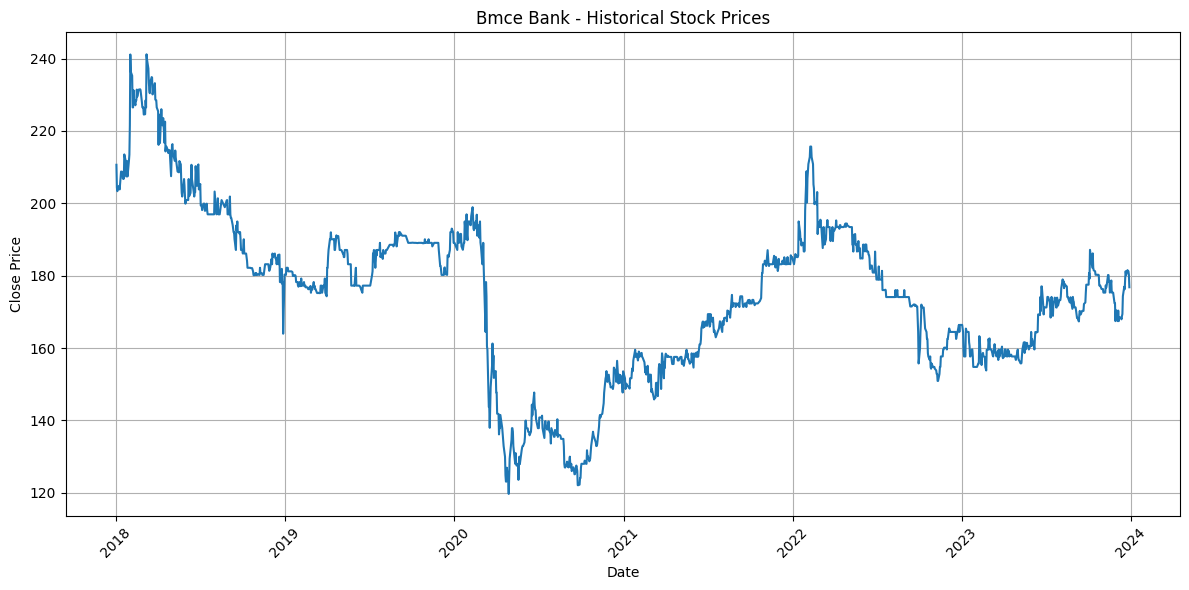

Training data: 1008 records
Validation data: 216 records
Test data: 217 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1510, Val Loss: 0.1603, Test Loss: 0.3473


Epoch [20/100], Train Loss: 0.0986, Val Loss: 0.0196, Test Loss: 0.9364


Epoch [30/100], Train Loss: 0.0473, Val Loss: 0.0125, Test Loss: 0.6131


...

Epoch [60/100], Train Loss: 0.0230, Val Loss: 0.0098, Test Loss: 0.1713


Epoch [70/100], Train Loss: 0.0229, Val Loss: 0.0089, Test Loss: 0.1518


Epoch [80/100], Train Loss: 0.0209, Val Loss: 0.0072, Test Loss: 0.1309


Epoch [90/100], Train Loss: 0.0200, Val Loss: 0.0057, Test Loss: 0.1009


Epoch [100/100], Train Loss: 0.0173, Val Loss: 0.0054, Test Loss: 0.0796
Training completed in 20.31 seconds


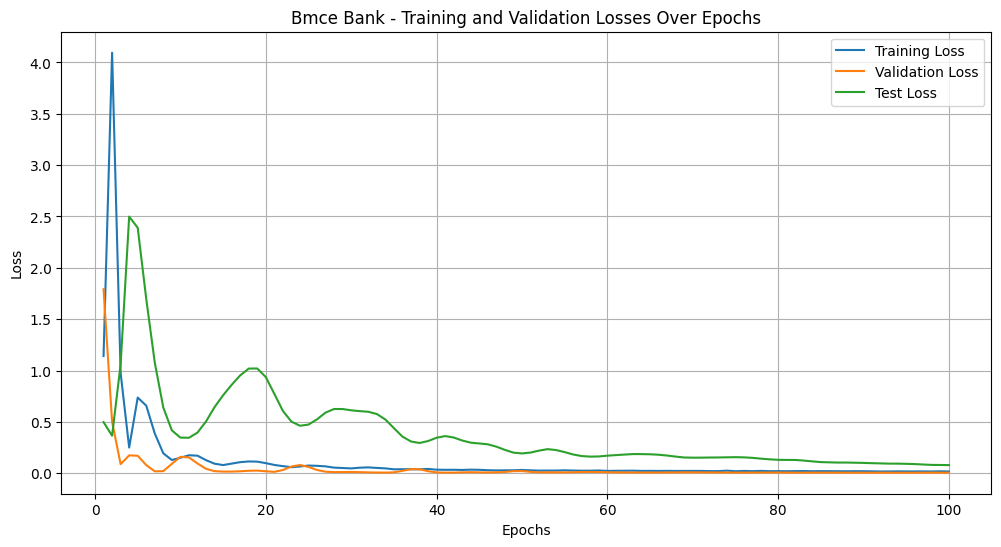


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0482
Mean Squared Error (MSE): 0.0054
Root Mean Squared Error (RMSE): 0.0737
Mean Absolute Percentage Error (MAPE): 29.0371
R² Score: 0.9116

Test Set Metrics:
Mean Absolute Error (MAE): 0.1790
Mean Squared Error (MSE): 0.0796
Root Mean Squared Error (RMSE): 0.2822
Mean Absolute Percentage Error (MAPE): 11.4338
R² Score: 0.8525


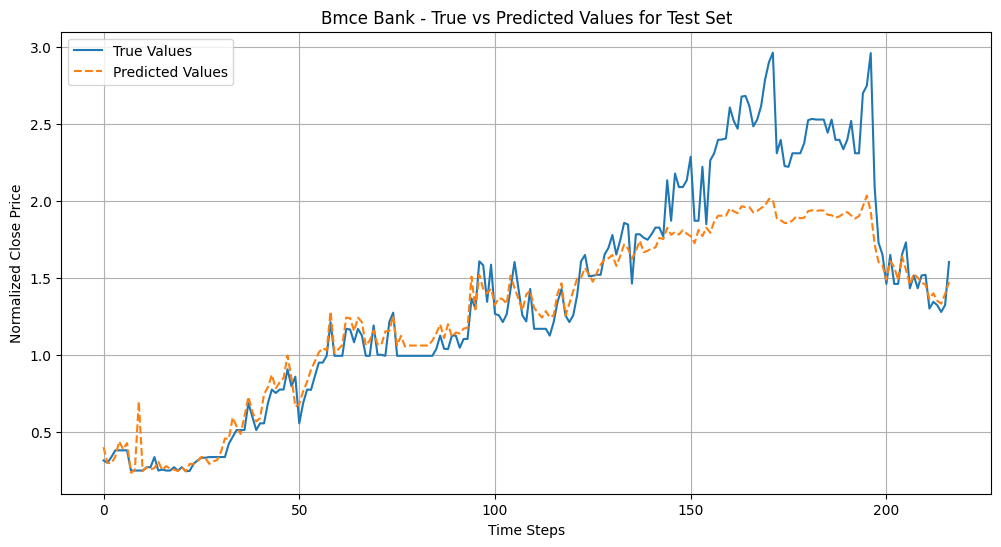


Correlation between true and predicted values: 0.9617

Processing Ciments Du Maroc
Loaded 1264 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


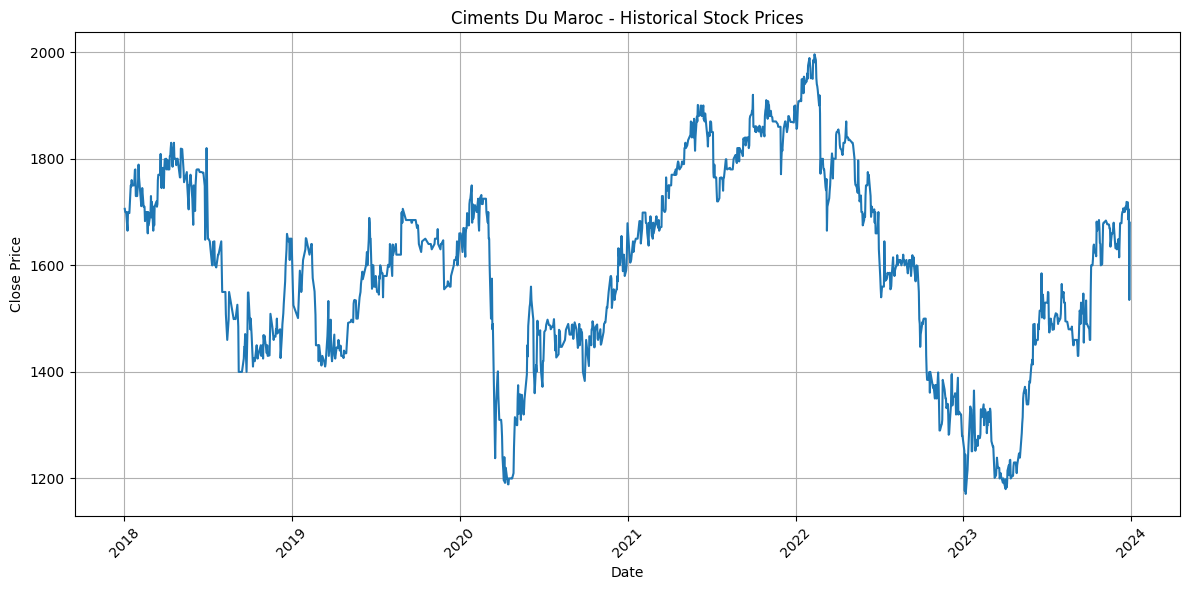

Training data: 884 records
Validation data: 189 records
Test data: 191 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1328, Val Loss: 0.1855, Test Loss: 0.2276


Epoch [20/100], Train Loss: 0.1242, Val Loss: 0.0117, Test Loss: 0.0117


Epoch [30/100], Train Loss: 0.0545, Val Loss: 0.0075, Test Loss: 0.0086


...

Epoch [60/100], Train Loss: 0.0310, Val Loss: 0.0063, Test Loss: 0.0086


Epoch [70/100], Train Loss: 0.0265, Val Loss: 0.0061, Test Loss: 0.0080


Epoch [80/100], Train Loss: 0.0255, Val Loss: 0.0060, Test Loss: 0.0066


Epoch [90/100], Train Loss: 0.0226, Val Loss: 0.0062, Test Loss: 0.0062


Epoch [100/100], Train Loss: 0.0215, Val Loss: 0.0057, Test Loss: 0.0060
Training completed in 17.62 seconds


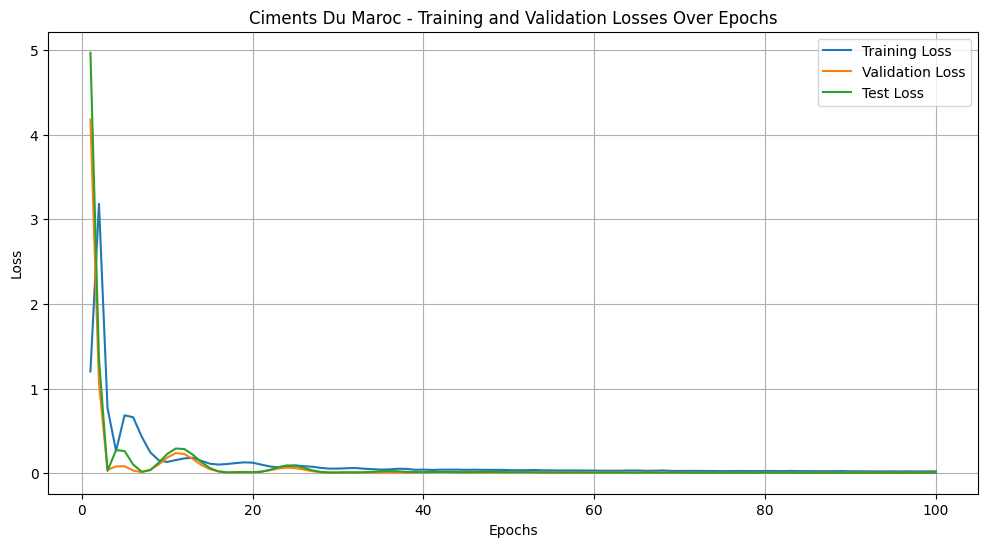


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0493
Mean Squared Error (MSE): 0.0057
Root Mean Squared Error (RMSE): 0.0758
Mean Absolute Percentage Error (MAPE): 49.4233
R² Score: 0.9741

Test Set Metrics:
Mean Absolute Error (MAE): 0.0540
Mean Squared Error (MSE): 0.0060
Root Mean Squared Error (RMSE): 0.0775
Mean Absolute Percentage Error (MAPE): 19.4089
R² Score: 0.9885


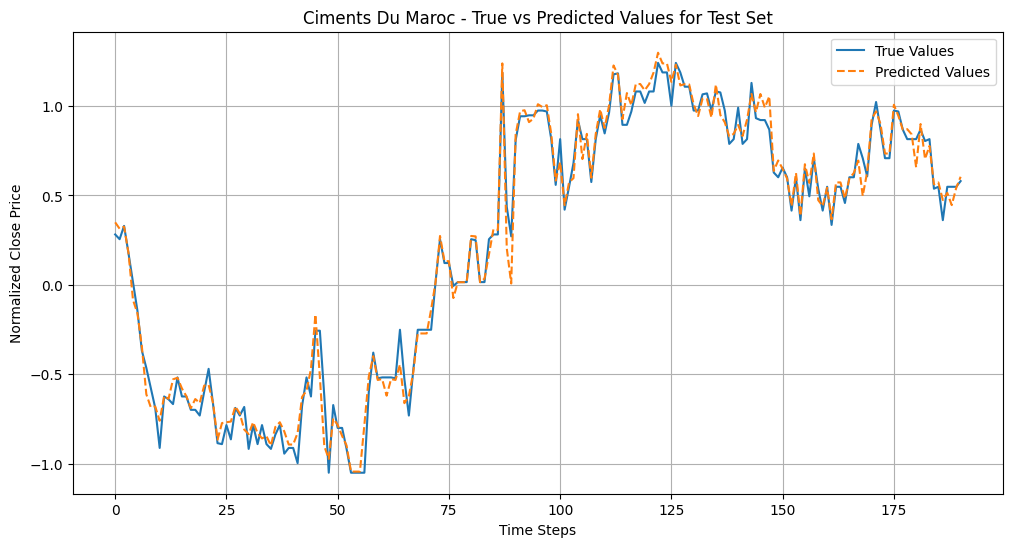


Correlation between true and predicted values: 0.9943

Processing Itissalat Al-Maghrib
Loaded 1491 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


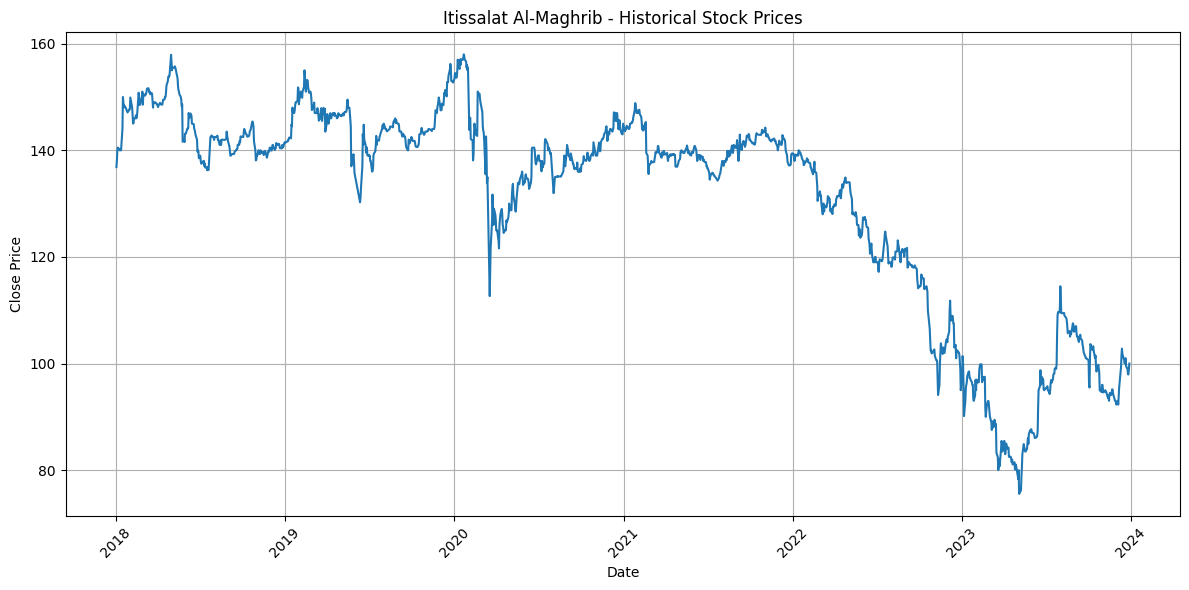

Training data: 1043 records
Validation data: 223 records
Test data: 225 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1566, Val Loss: 0.1014, Test Loss: 0.1063


Epoch [20/100], Train Loss: 0.0586, Val Loss: 0.0223, Test Loss: 0.0385


Epoch [30/100], Train Loss: 0.0542, Val Loss: 0.0144, Test Loss: 0.0278


...

Epoch [60/100], Train Loss: 0.0211, Val Loss: 0.0051, Test Loss: 0.0043


Epoch [70/100], Train Loss: 0.0199, Val Loss: 0.0070, Test Loss: 0.0066


Epoch [80/100], Train Loss: 0.0179, Val Loss: 0.0073, Test Loss: 0.0080


Epoch [90/100], Train Loss: 0.0161, Val Loss: 0.0075, Test Loss: 0.0088


Epoch [100/100], Train Loss: 0.0147, Val Loss: 0.0077, Test Loss: 0.0094
Training completed in 20.64 seconds


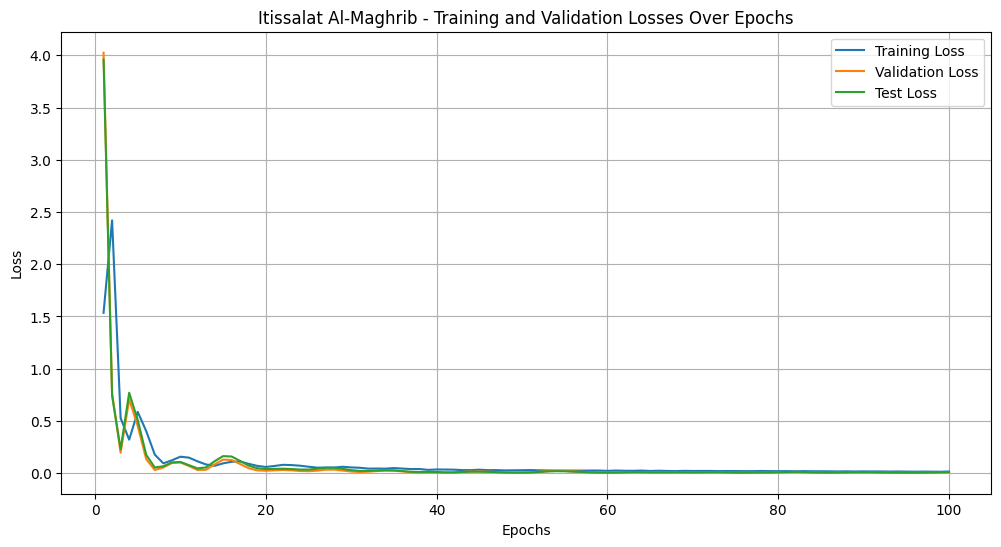


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0690
Mean Squared Error (MSE): 0.0077
Root Mean Squared Error (RMSE): 0.0877
Mean Absolute Percentage Error (MAPE): 11.6056
R² Score: 0.8251

Test Set Metrics:
Mean Absolute Error (MAE): 0.0818
Mean Squared Error (MSE): 0.0094
Root Mean Squared Error (RMSE): 0.0972
Mean Absolute Percentage Error (MAPE): 11.3307
R² Score: 0.8589


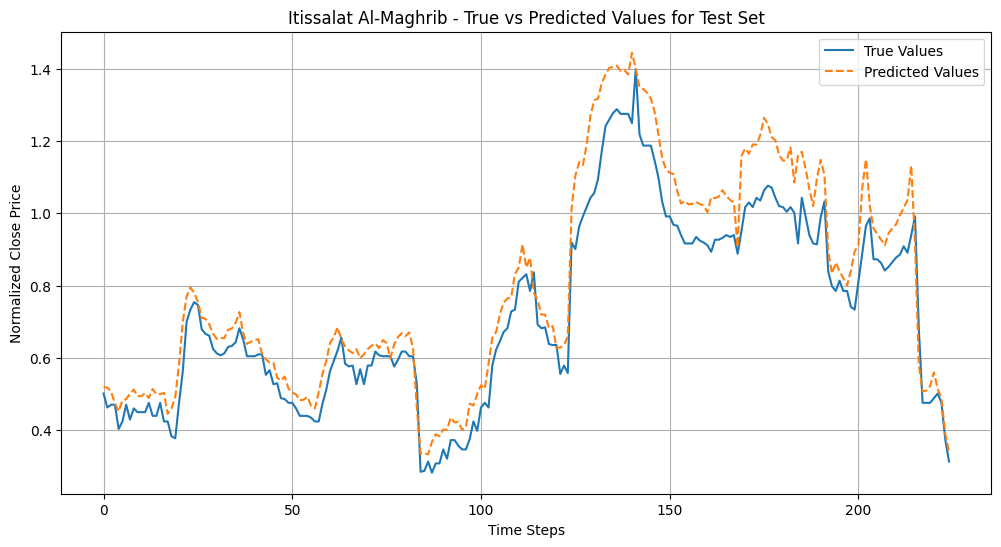


Correlation between true and predicted values: 0.9878

Processing LafargeHolcim Maroc
Loaded 1347 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


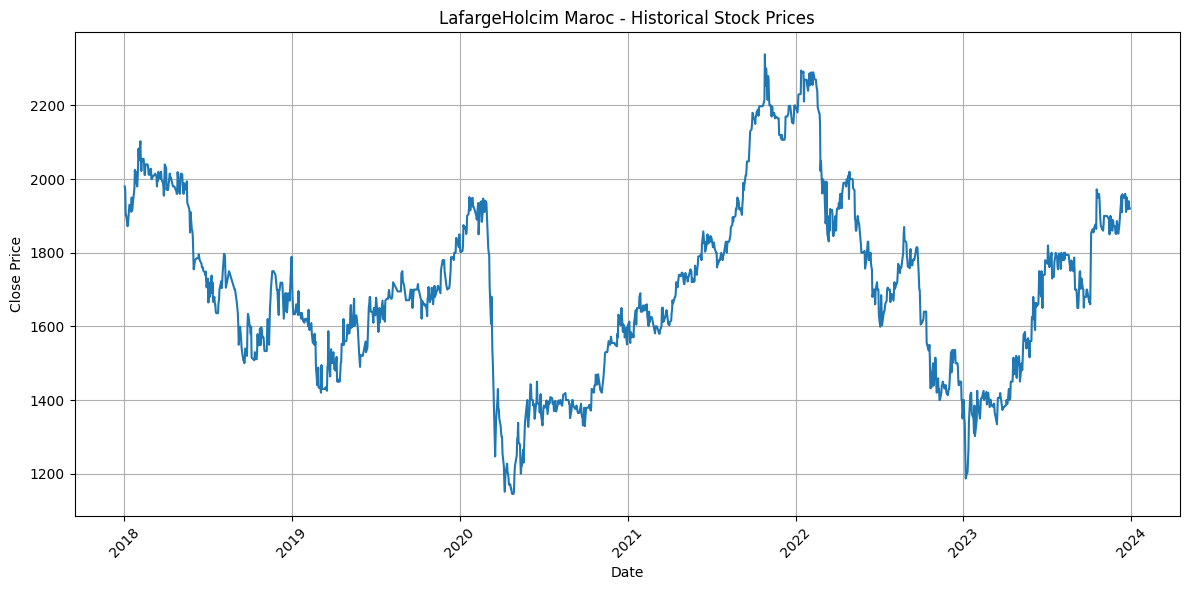

Training data: 942 records
Validation data: 202 records
Test data: 203 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1519, Val Loss: 0.1655, Test Loss: 0.2239


Epoch [20/100], Train Loss: 0.0589, Val Loss: 0.0503, Test Loss: 0.1378


Epoch [30/100], Train Loss: 0.0369, Val Loss: 0.0132, Test Loss: 0.0099


...

Epoch [60/100], Train Loss: 0.0238, Val Loss: 0.0055, Test Loss: 0.0086


Epoch [70/100], Train Loss: 0.0214, Val Loss: 0.0057, Test Loss: 0.0078


Epoch [80/100], Train Loss: 0.0188, Val Loss: 0.0072, Test Loss: 0.0099


Epoch [90/100], Train Loss: 0.0170, Val Loss: 0.0058, Test Loss: 0.0075


Epoch [100/100], Train Loss: 0.0153, Val Loss: 0.0058, Test Loss: 0.0073
Training completed in 19.32 seconds


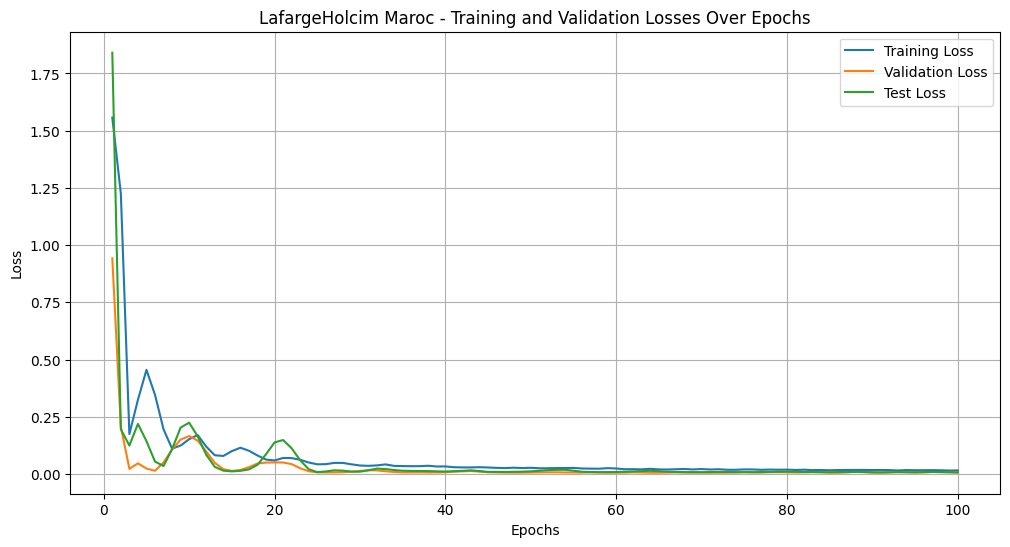


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0531
Mean Squared Error (MSE): 0.0058
Root Mean Squared Error (RMSE): 0.0764
Mean Absolute Percentage Error (MAPE): 115.8798
R² Score: 0.9572

Test Set Metrics:
Mean Absolute Error (MAE): 0.0603
Mean Squared Error (MSE): 0.0073
Root Mean Squared Error (RMSE): 0.0852
Mean Absolute Percentage Error (MAPE): 44.1974
R² Score: 0.9868


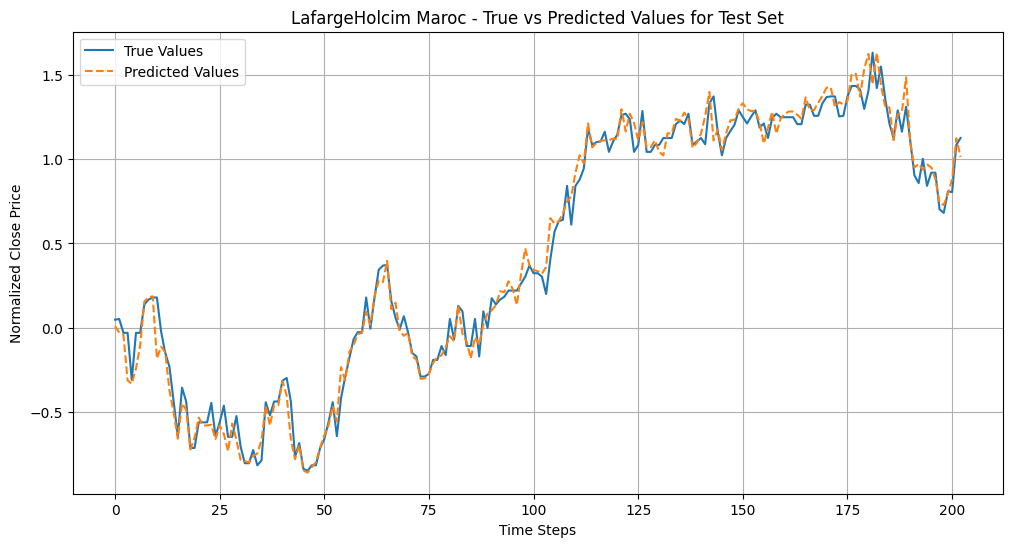


Correlation between true and predicted values: 0.9940

Processing Managem
Loaded 1377 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


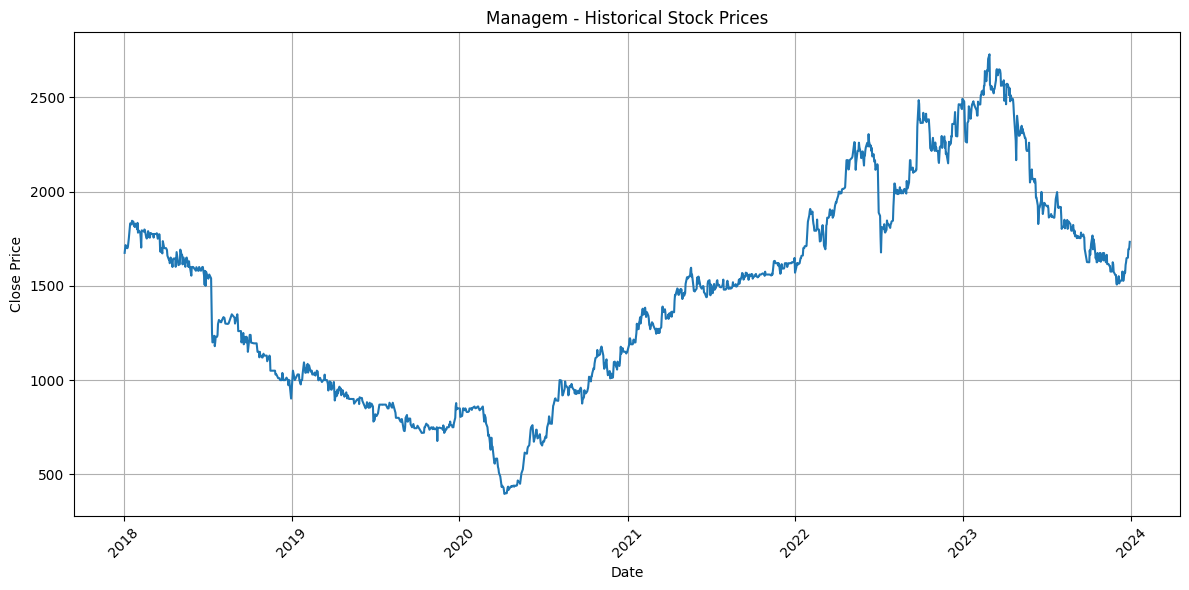

Training data: 963 records
Validation data: 206 records
Test data: 208 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1581, Val Loss: 0.0591, Test Loss: 0.1428


Epoch [20/100], Train Loss: 0.0961, Val Loss: 0.0229, Test Loss: 0.0066


Epoch [30/100], Train Loss: 0.0482, Val Loss: 0.1031, Test Loss: 0.0457


...

Epoch [60/100], Train Loss: 0.0186, Val Loss: 0.0016, Test Loss: 0.0034


Epoch [70/100], Train Loss: 0.0165, Val Loss: 0.0055, Test Loss: 0.0019


Epoch [80/100], Train Loss: 0.0138, Val Loss: 0.0039, Test Loss: 0.0020


Epoch [90/100], Train Loss: 0.0144, Val Loss: 0.0026, Test Loss: 0.0015


Epoch [100/100], Train Loss: 0.0130, Val Loss: 0.0020, Test Loss: 0.0014
Training completed in 19.40 seconds


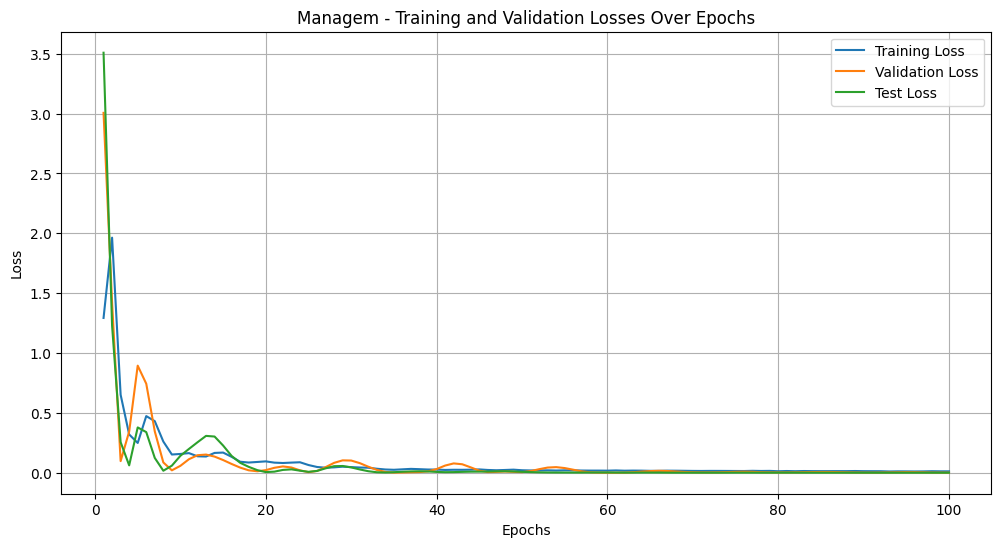


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0367
Mean Squared Error (MSE): 0.0020
Root Mean Squared Error (RMSE): 0.0449
Mean Absolute Percentage Error (MAPE): 3.1367
R² Score: 0.9391

Test Set Metrics:
Mean Absolute Error (MAE): 0.0252
Mean Squared Error (MSE): 0.0014
Root Mean Squared Error (RMSE): 0.0376
Mean Absolute Percentage Error (MAPE): 8.0432
R² Score: 0.9949


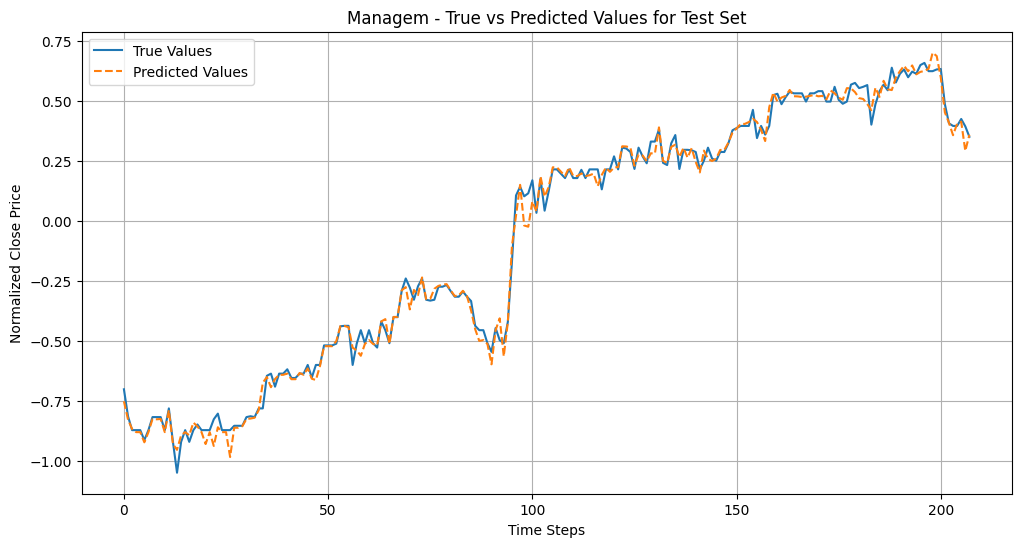


Correlation between true and predicted values: 0.9975

Processing Societe d'Exploitation des Ports
Loaded 1489 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


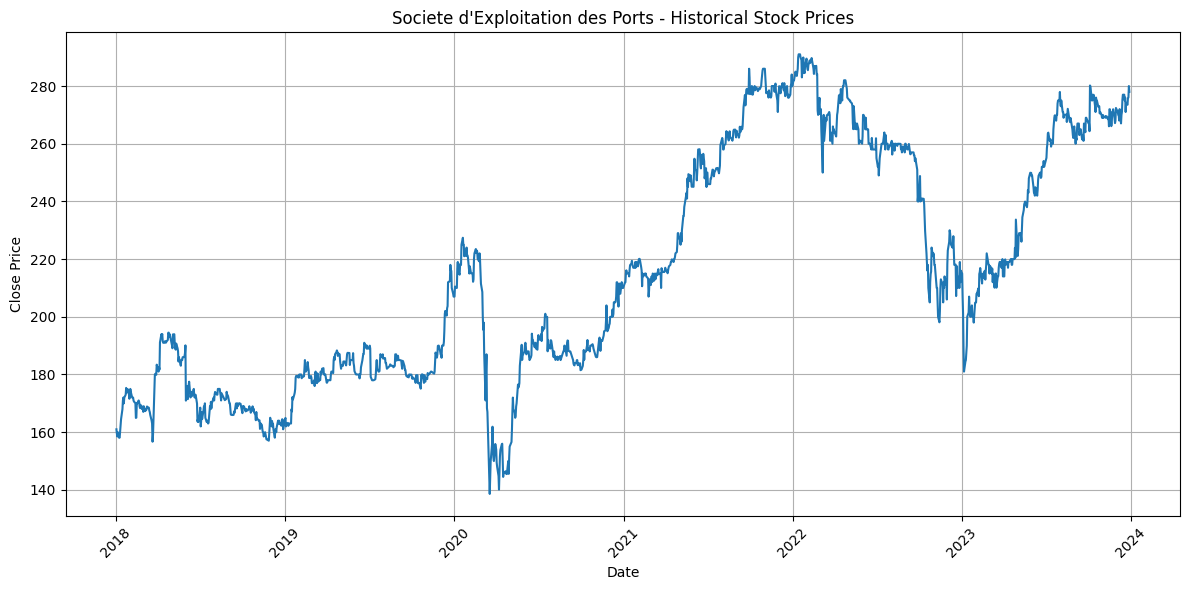

Training data: 1042 records
Validation data: 223 records
Test data: 224 records


Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1204, Val Loss: 0.1878, Test Loss: 0.1149


Epoch [20/100], Train Loss: 0.0543, Val Loss: 0.0144, Test Loss: 0.0113


...

Epoch [60/100], Train Loss: 0.0184, Val Loss: 0.0060, Test Loss: 0.0158


Epoch [70/100], Train Loss: 0.0173, Val Loss: 0.0052, Test Loss: 0.0123


Epoch [80/100], Train Loss: 0.0153, Val Loss: 0.0066, Test Loss: 0.0156


Epoch [90/100], Train Loss: 0.0138, Val Loss: 0.0070, Test Loss: 0.0166


Epoch [100/100], Train Loss: 0.0117, Val Loss: 0.0088, Test Loss: 0.0211
Training completed in 21.13 seconds


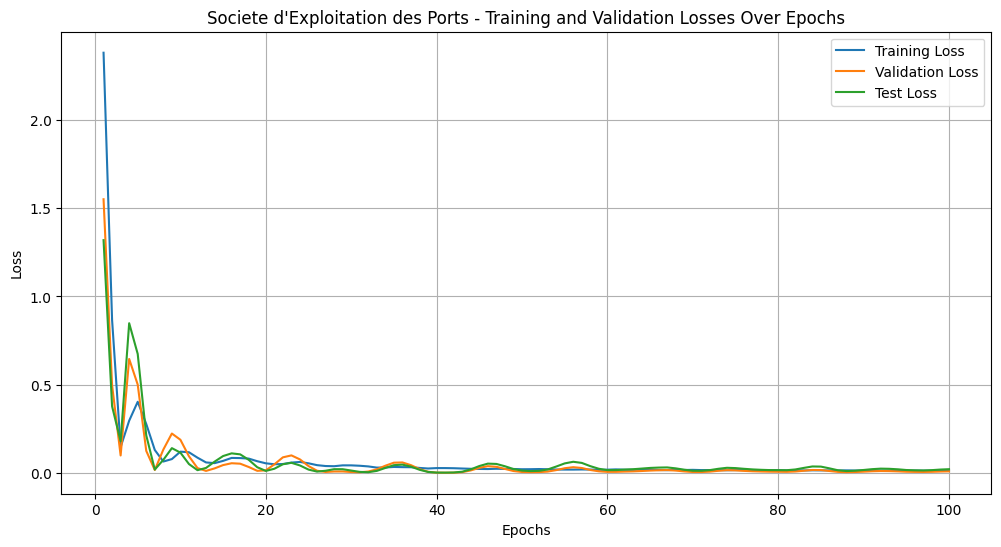


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0707
Mean Squared Error (MSE): 0.0088
Root Mean Squared Error (RMSE): 0.0937
Mean Absolute Percentage Error (MAPE): 7.2573
R² Score: 0.7475

Test Set Metrics:
Mean Absolute Error (MAE): 0.1286
Mean Squared Error (MSE): 0.0211
Root Mean Squared Error (RMSE): 0.1451
Mean Absolute Percentage Error (MAPE): 11.3532
R² Score: 0.6141


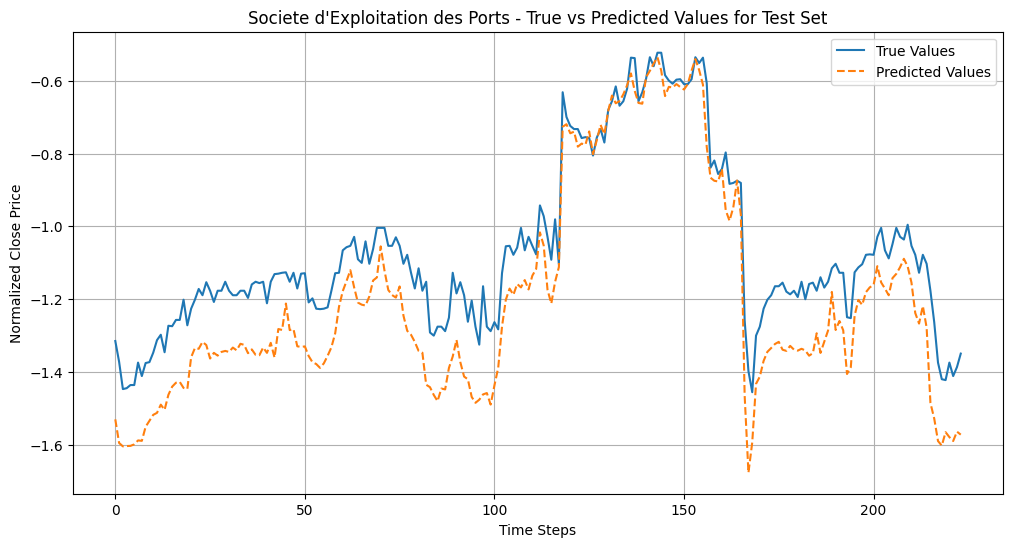


Correlation between true and predicted values: 0.9883

Processing Taqa Morocco SA
Loaded 1343 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


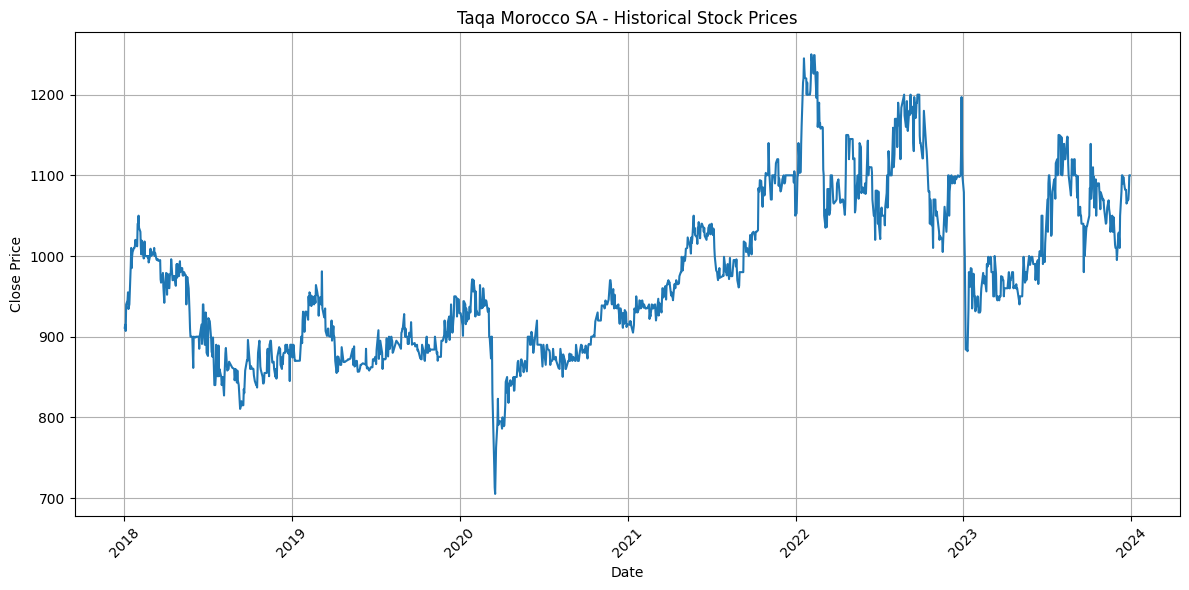

Training data: 940 records
Validation data: 201 records
Test data: 202 records
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.1471, Val Loss: 0.1438, Test Loss: 0.1147


Epoch [20/100], Train Loss: 0.0839, Val Loss: 0.0116, Test Loss: 0.0262


Epoch [30/100], Train Loss: 0.0576, Val Loss: 0.0199, Test Loss: 0.0185


...

Epoch [60/100], Train Loss: 0.0299, Val Loss: 0.0075, Test Loss: 0.0192


Epoch [70/100], Train Loss: 0.0266, Val Loss: 0.0076, Test Loss: 0.0169


Epoch [80/100], Train Loss: 0.0247, Val Loss: 0.0057, Test Loss: 0.0116


Epoch [90/100], Train Loss: 0.0220, Val Loss: 0.0057, Test Loss: 0.0118


Epoch [100/100], Train Loss: 0.0208, Val Loss: 0.0048, Test Loss: 0.0098
Training completed in 18.76 seconds


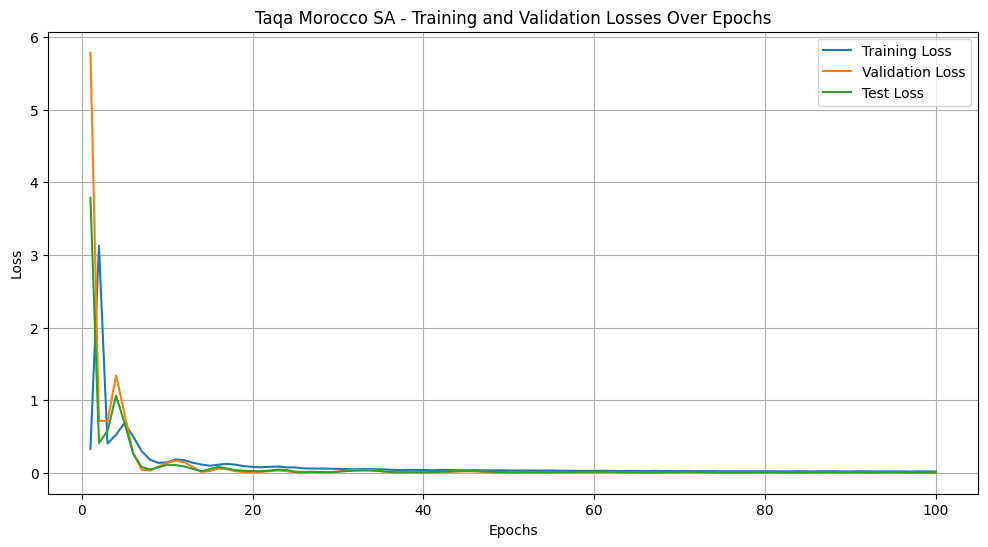


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0505
Mean Squared Error (MSE): 0.0048
Root Mean Squared Error (RMSE): 0.0694
Mean Absolute Percentage Error (MAPE): 8.1819
R² Score: 0.9367

Test Set Metrics:
Mean Absolute Error (MAE): 0.0729
Mean Squared Error (MSE): 0.0098
Root Mean Squared Error (RMSE): 0.0989
Mean Absolute Percentage Error (MAPE): 204.1192
R² Score: 0.9775


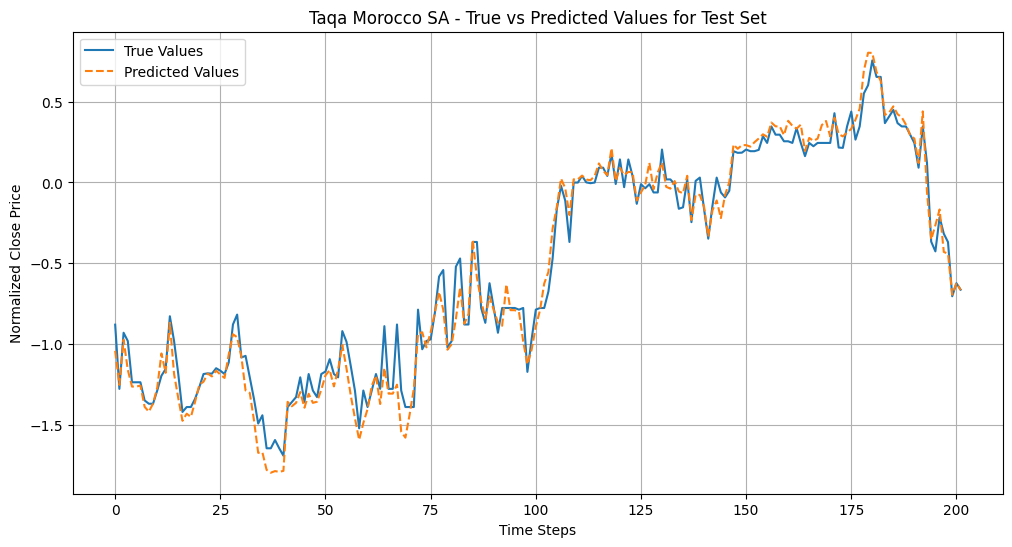


Correlation between true and predicted values: 0.9922

Processing Travaux Generaux De Construction
Loaded 513 records
Columns in the loaded data: ['Date', 'Open', 'High', 'Low', 'Close']


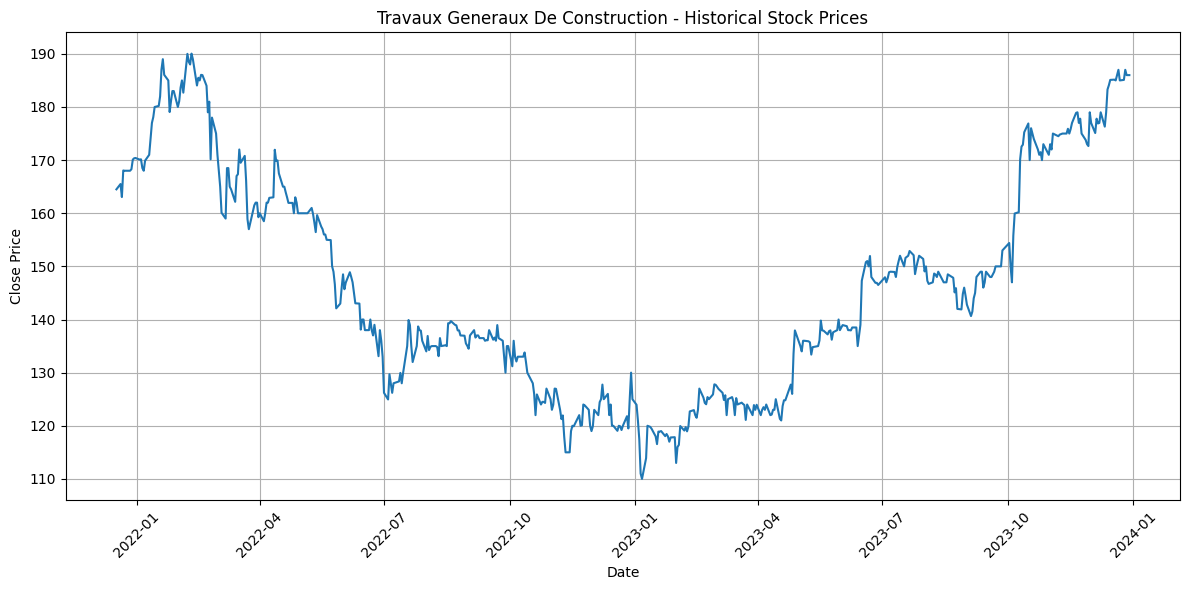

Training data: 359 records
Validation data: 76 records
Test data: 78 records


Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Epoch [10/100], Train Loss: 0.0789, Val Loss: 0.2875, Test Loss: 0.3410


Epoch [20/100], Train Loss: 0.0697, Val Loss: 0.0472, Test Loss: 0.1268


...

Epoch [60/100], Train Loss: 0.0201, Val Loss: 0.0135, Test Loss: 0.0274


Epoch [70/100], Train Loss: 0.0179, Val Loss: 0.0119, Test Loss: 0.0263


Epoch [80/100], Train Loss: 0.0149, Val Loss: 0.0121, Test Loss: 0.0256


Epoch [90/100], Train Loss: 0.0161, Val Loss: 0.0113, Test Loss: 0.0221


Epoch [100/100], Train Loss: 0.0149, Val Loss: 0.0113, Test Loss: 0.0199
Training completed in 9.58 seconds


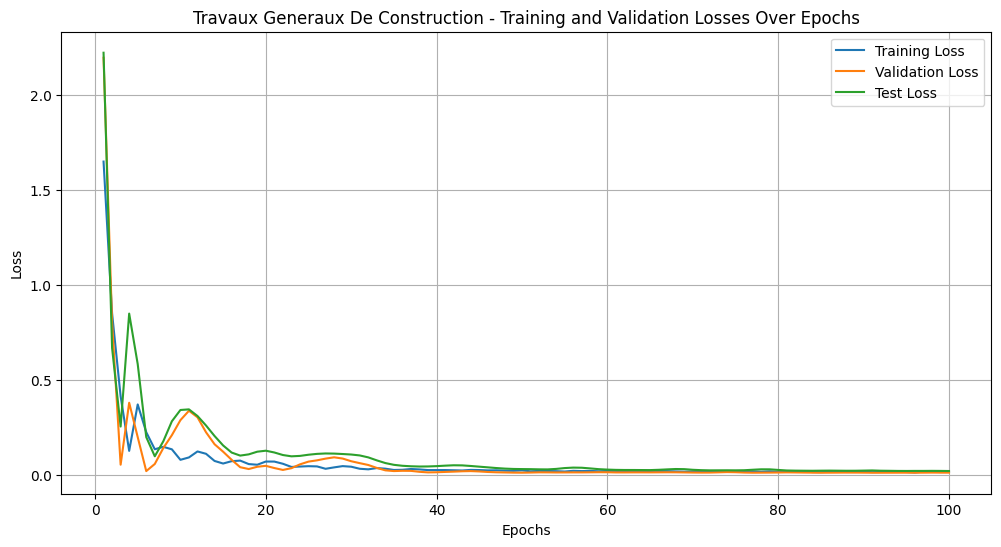


Validation Set Metrics:
Mean Absolute Error (MAE): 0.0877
Mean Squared Error (MSE): 0.0113
Root Mean Squared Error (RMSE): 0.1064
Mean Absolute Percentage Error (MAPE): 30.0630
R² Score: 0.9706

Test Set Metrics:
Mean Absolute Error (MAE): 0.0996
Mean Squared Error (MSE): 0.0199
Root Mean Squared Error (RMSE): 0.1412
Mean Absolute Percentage Error (MAPE): 9.3604
R² Score: 0.9070


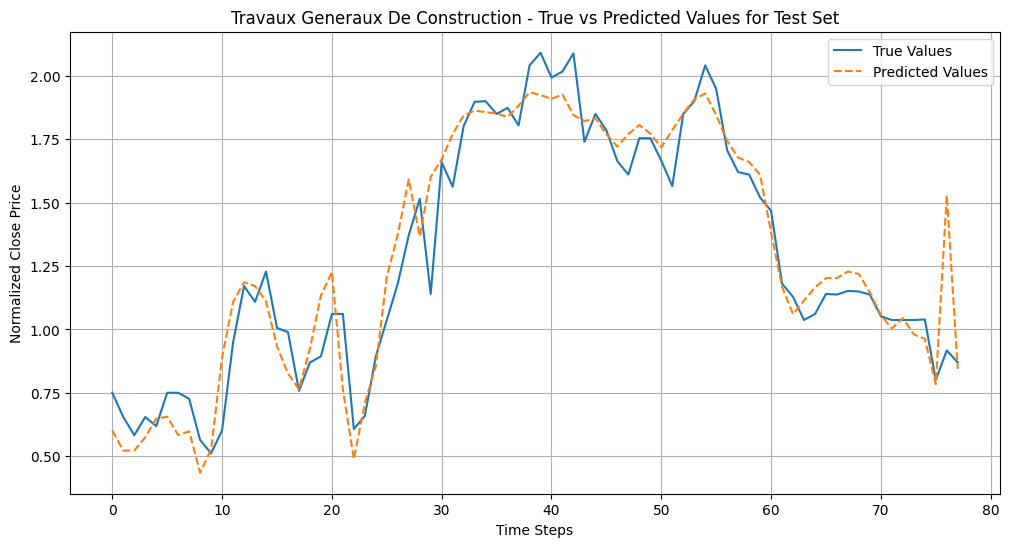


Correlation between true and predicted values: 0.9551


In [5]:
results = []
for company_name, file_name in companies.items():
    result = process_and_predict_stock(DATA_DIR / file_name, company_name)
    if result:
        results.append(result)

## Summary across companies


SUMMARY OF RESULTS FOR MOROCCAN COMPANIES
                         Company      MAE     RMSE       MAPE       R²  Correlation  Training Time (s)
               Attijariwafa Bank 0.087813 0.106239  35.128288 0.967831     0.988429          21.704018
                             BCP 0.114112 0.147099  18.059952 0.928907     0.971501          21.312970
                       Bmce Bank 0.179016 0.282153  11.433753 0.852504     0.961742          20.307634
                Ciments Du Maroc 0.054040 0.077517  19.408945 0.988468     0.994295          17.619796
            Itissalat Al-Maghrib 0.081813 0.097181  11.330656 0.858917     0.987844          20.643594
             LafargeHolcim Maroc 0.060291 0.085200  44.197445 0.986762     0.994046          19.317983
                         Managem 0.025205 0.037599   8.043154 0.994862     0.997516          19.404475
Societe d'Exploitation des Ports 0.128583 0.145098  11.353237 0.614102     0.988286          21.129216
                 Taqa Morocco 

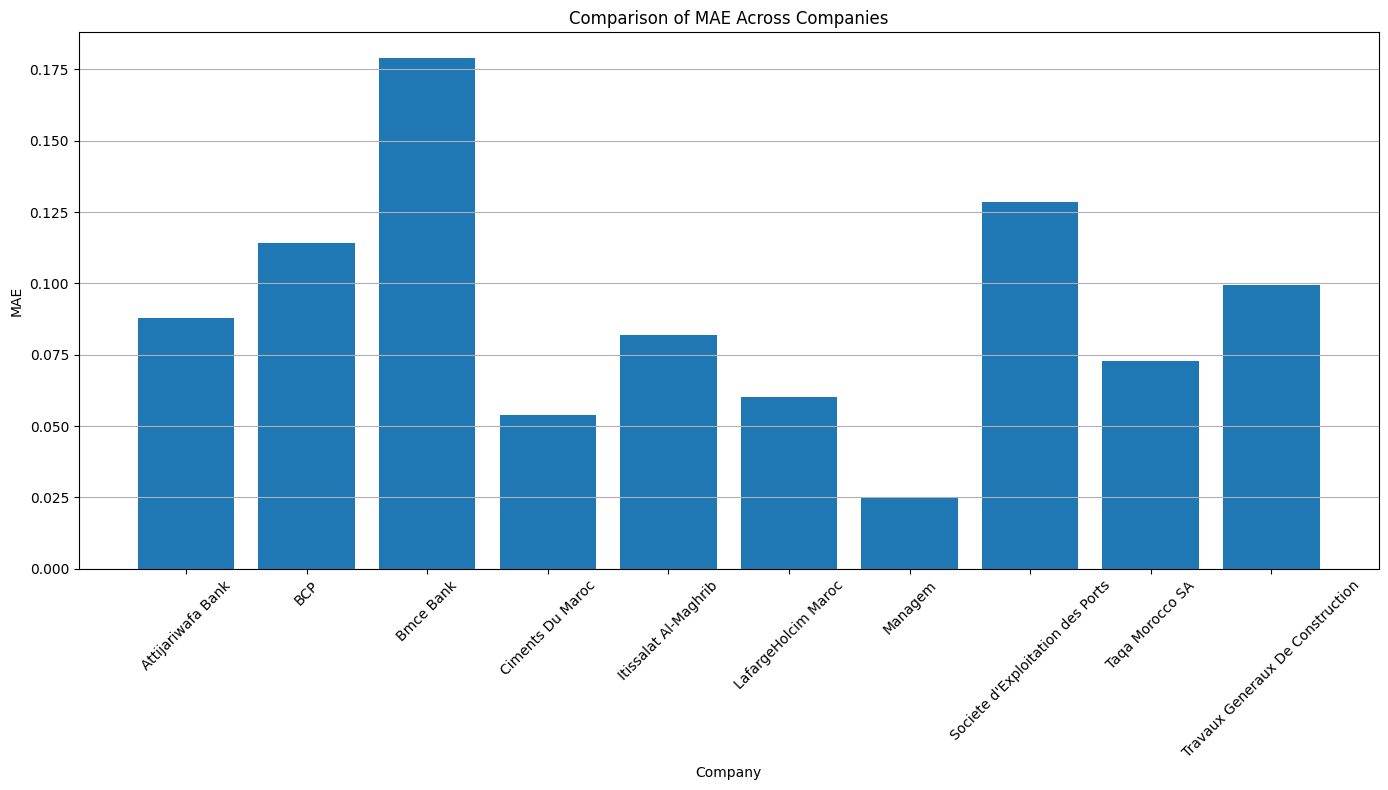

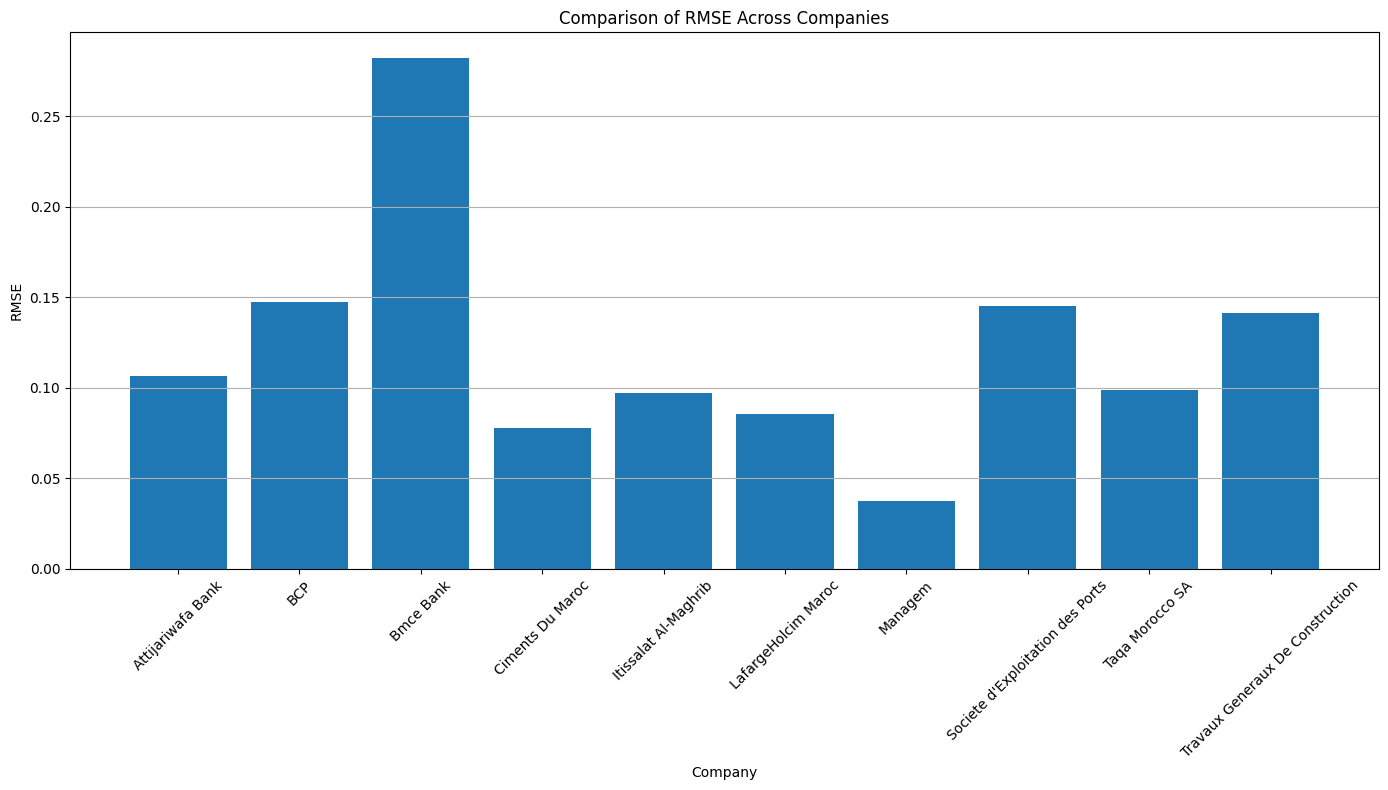

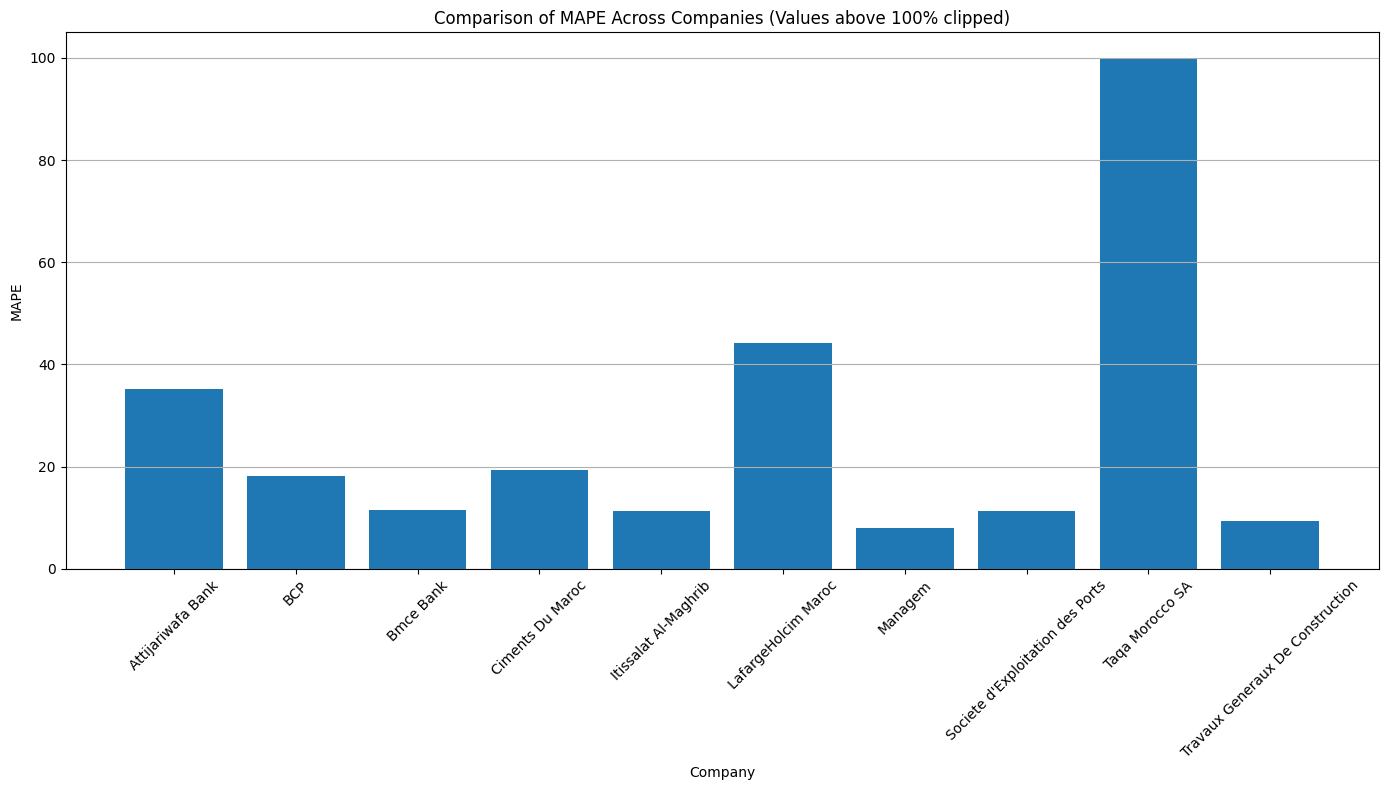

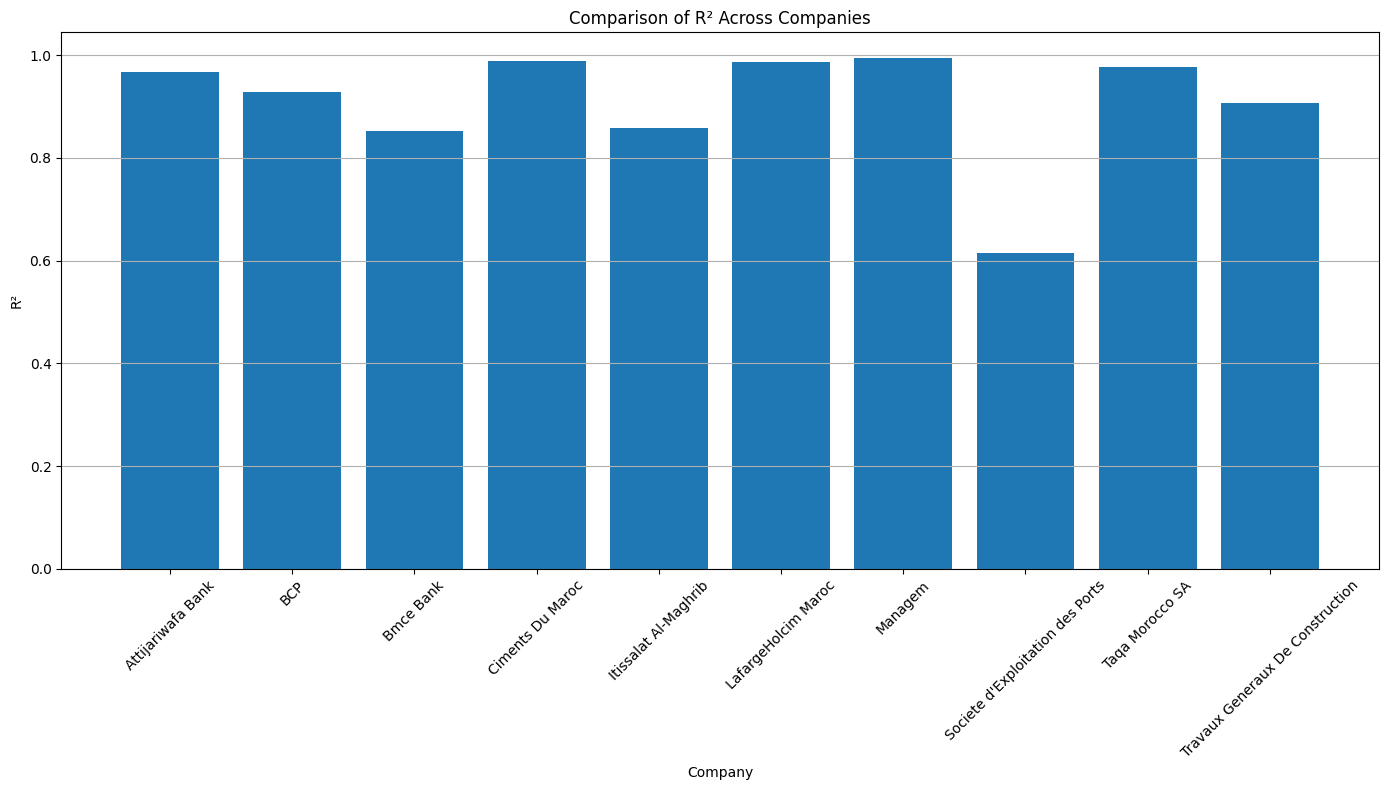

In [6]:
# Creating a summary table of results
if results:
    print("\n" + "="*80)
    print("SUMMARY OF RESULTS FOR MOROCCAN COMPANIES")
    print("="*80)

    # Creating a table with our results
    comparison_data = []
    for result in results:
        company = result['company']
        comparison_data.append({
            'Company': company,
            'MAE': result['metrics']['mae'],
            'RMSE': result['metrics']['rmse'],
            'MAPE': result['metrics']['mape'],
            'R²': result['metrics']['r2'],
            'Correlation': result['metrics']['correlation'],
            'Training Time (s)': result['training_time']
        })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

    # Saving the summary so it can be compared across runs
    RESULTS_DIR.mkdir(exist_ok=True)
    comparison_df.to_csv(RESULTS_DIR / "summary_metrics.csv", index=False)
    print(f"\nSaved summary to {RESULTS_DIR / 'summary_metrics.csv'}")

    # Plotting a comparison of metrics across companies
    metrics = ['MAE', 'RMSE', 'MAPE', 'R²']

    for metric in metrics:
        plt.figure(figsize=(14, 8))
        companies = comparison_df['Company'].tolist()
        values = comparison_df[metric].tolist()

        # For MAPE, we'll clip very large values for better visualization
        if metric == 'MAPE' and max(values) > 100:
            values = [min(v, 100) for v in values]
            plt.title(f'Comparison of {metric} Across Companies (Values above 100% clipped)')
        else:
            plt.title(f'Comparison of {metric} Across Companies')

        plt.bar(companies, values)
        plt.xlabel('Company')
        plt.ylabel(metric)
        plt.xticks(rotation=45)
        plt.grid(True, axis='y')
        plt.tight_layout()
        plt.show()
else:
    print("No results to compare.")